# KV cache benchmark harness

Measures decoding speed and memory for the `vanilla=True` (no cache, recomputes
full context every step) vs `vanilla=False` (KV cache) paths in `mingpt/model.py`,
following the harness spec in `CLAUDE.md`.

**Order matters**: this harness is written and validated *before* any new
generation method (speculative decoding) is added, and it is run against the
already-fixed `generate` as the baseline. Do not use this notebook's numbers if
the `attn_vanilla` double-compute bug is still present in `model.py` — every
timing here silently doubles otherwise.

**Device note**: this machine has `torch==2.6.0+cpu`, no CUDA. All the
`torch.cuda.*` calls below are gated behind a device check so the harness runs
here for correctness/debugging, but the CPU numbers are **not** the thesis
numbers — VRAM metrics are `None` on CPU, and CPU wall-clock timing has much
higher relative noise than a quiet GPU. Re-run this notebook on Colab (GPU) to
produce the numbers that actually go in the thesis; only the harness logic is
being validated locally.


In [11]:
import json
import math
import platform
import time
from pathlib import Path

import torch

from mingpt.model import GPT
from mingpt.utils import set_seed

SEED = 3407
set_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def device_name():
    if DEVICE == 'cuda':
        return torch.cuda.get_device_name()
    return f"CPU: {platform.processor() or platform.machine()}"

print(f"device        = {DEVICE}")
print(f"device_name   = {device_name()}")
print(f"torch version = {torch.__version__}")


device        = cpu
device_name   = CPU: Intel64 Family 6 Model 154 Stepping 3, GenuineIntel
torch version = 2.6.0+cpu


## Timing / memory primitives

`torch.cuda.synchronize()` and `torch.cuda.reset_peak_memory_stats()` are only
meaningful (and only defined without error) on CUDA — these wrappers make them
no-ops on CPU instead of the harness crashing outright.


In [12]:
def device_sync():
    if DEVICE == 'cuda':
        torch.cuda.synchronize()

def reset_peak_memory():
    if DEVICE == 'cuda':
        torch.cuda.reset_peak_memory_stats()

def peak_memory_bytes():
    if DEVICE == 'cuda':
        return torch.cuda.max_memory_allocated()
    return None  # not tracked on CPU; see device note above


## KV cache memory: analytical vs measured

Analytical formula from `CLAUDE.md`: `2 * B * L * n_embd * T * bytes_per_element`
(the factor 2 is K and V; `n_embd` already sums over all heads since
`n_embd = n_head * head_size`).


In [13]:
def analytical_kv_cache_bytes(batch, n_layer, n_embd, seq_len, dtype=torch.float32):
    return 2 * batch * n_layer * n_embd * seq_len * torch.tensor([], dtype=dtype).element_size()

def measured_kv_cache_bytes(model):
    total = 0
    for block in model.transformer.h:
        k = getattr(block.attn, 'k_cache', None)
        v = getattr(block.attn, 'v_cache', None)
        if k is not None:
            total += k.numel() * k.element_size()
        if v is not None:
            total += v.numel() * v.element_size()
    return total


## Core measurement

One call = one full timed generation, split into TTFT (prefill) and total time,
so `TPOT = (total_time - TTFT) / (generated_tokens - 1)` per the metric table.

TTFT is measured with a dedicated prefill-only forward pass (`model(idx_cond,
False)`), *not* by instrumenting `generate()` — this keeps `generate()`
untouched as the correctness reference and works identically for `vanilla=True`
and `vanilla=False` models, since the `kv_cached` flag on `forward` only
controls the position-embedding offset (see `model.py` `forward`). The cache
is reset before and after the probe so it doesn't contaminate the timed
`generate()` call that follows.


In [14]:
@torch.no_grad()
def run_once(model, idx, max_new_tokens, do_sample=False, top_k=None, temperature=1.0):
    idx_cond = idx if idx.size(1) <= model.block_size else idx[:, -model.block_size:]

    # --- TTFT: dedicated prefill-only forward pass ---
    if not model.vanilla:
        model.reset_kv_cache()
    device_sync()
    t0 = time.perf_counter()
    model(idx_cond, False)
    device_sync()
    t1 = time.perf_counter()
    ttft = t1 - t0
    if not model.vanilla:
        model.reset_kv_cache()

    # --- full generation, timed as a whole ---
    reset_peak_memory()
    device_sync()
    t2 = time.perf_counter()
    out = model.generate(idx, max_new_tokens=max_new_tokens, do_sample=do_sample,
                          top_k=top_k, temperature=temperature)
    device_sync()
    t3 = time.perf_counter()
    total_time = t3 - t2

    generated_tokens = max_new_tokens
    tpot = (total_time - ttft) / (generated_tokens - 1) if generated_tokens > 1 else float('nan')
    throughput = generated_tokens / total_time

    kv_measured = measured_kv_cache_bytes(model) if not model.vanilla else 0
    seq_len = out.size(1)
    kv_analytical = analytical_kv_cache_bytes(out.size(0), model.num_layers,
                                               model.transformer.wte.embedding_dim, seq_len)

    return {
        'ttft': ttft,
        'total_time': total_time,
        'tpot': tpot,
        'throughput': throughput,
        'peak_memory_bytes': peak_memory_bytes(),
        'kv_cache_measured_bytes': kv_measured,
        'kv_cache_analytical_bytes': kv_analytical,
        'seq_len': seq_len,
        'out': out,
    }


## Benchmark harness: warmup + N=5 repeats, median/range

Per spec: 3 warmup iterations (untimed, just to settle allocator/caches), then
N=5 timed repeats, reporting median and (min, max) range rather than only the
mean.


In [15]:
def _median(xs):
    xs = sorted(xs)
    n = len(xs)
    mid = n // 2
    if n % 2 == 1:
        return xs[mid]
    return (xs[mid - 1] + xs[mid]) / 2

def summarize(values):
    values = [v for v in values if v is not None]
    if not values:
        return {'median': None, 'min': None, 'max': None}
    return {'median': _median(values), 'min': min(values), 'max': max(values)}

def benchmark_config(model, idx, max_new_tokens, n_warmup=3, n_reps=5, **gen_kwargs):
    for _ in range(n_warmup):
        run_once(model, idx, max_new_tokens, **gen_kwargs)

    metrics = ['ttft', 'total_time', 'tpot', 'throughput', 'peak_memory_bytes',
               'kv_cache_measured_bytes', 'kv_cache_analytical_bytes']
    raw = {m: [] for m in metrics}
    for _ in range(n_reps):
        result = run_once(model, idx, max_new_tokens, **gen_kwargs)
        for m in metrics:
            raw[m].append(result[m])

    return {
        'n_warmup': n_warmup,
        'n_reps': n_reps,
        'prompt_len': idx.size(1),
        'max_new_tokens': max_new_tokens,
        'raw': raw,
        'summary': {m: summarize(raw[m]) for m in metrics},
    }


## Result persistence (JSON + metadata)

Locally this writes under `./bench_results/`. **On Colab**, mount Drive first
and point `RESULTS_DIR` at it, e.g.
`RESULTS_DIR = Path('/content/drive/MyDrive/thesis/bench_results')`, so raw
results survive session resets.


In [16]:
RESULTS_DIR = Path('bench_results')
RESULTS_DIR.mkdir(exist_ok=True)

def save_result(name, model_type, cached, benchmark_result):
    payload = {
        'metadata': {
            'gpu_type': device_name(),
            'device': DEVICE,
            'torch_version': torch.__version__,
            'seed': SEED,
            'model_type': model_type,
            'cached': cached,
            'prompt_len': benchmark_result['prompt_len'],
            'max_new_tokens': benchmark_result['max_new_tokens'],
        },
        'summary': benchmark_result['summary'],
        'raw': benchmark_result['raw'],
    }
    path = RESULTS_DIR / f"{name}.json"
    with open(path, 'w') as f:
        json.dump(payload, f, indent=2)
    return path


## Smoke test

Confirms the harness runs end-to-end and produces sane numbers. Uses
`gpt-nano` with tiny rep counts so this executes in seconds on CPU — **not**
a real measurement, just a pipeline check. Delete/skip this cell's assertions
once you trust the harness; keep re-running it after any change to
`run_once`/`benchmark_config`.


In [17]:
def make_toy_config(model_type='gpt-nano', vocab_size=100, block_size=64):
    config = GPT.get_default_config()
    config.model_type = model_type
    config.vocab_size = vocab_size
    config.block_size = block_size
    return config

set_seed(1234)
toy_cached = GPT(make_toy_config(), vanilla=False).to(DEVICE).eval()
set_seed(1234)
toy_baseline = GPT(make_toy_config(), vanilla=True).to(DEVICE).eval()

toy_prompt = torch.randint(0, 100, (1, 8), device=DEVICE)

smoke_cached = benchmark_config(toy_cached, toy_prompt, max_new_tokens=10, n_warmup=1, n_reps=2)
smoke_baseline = benchmark_config(toy_baseline, toy_prompt, max_new_tokens=10, n_warmup=1, n_reps=2)

assert smoke_cached['summary']['tpot']['median'] is not None
assert smoke_baseline['summary']['tpot']['median'] is not None
assert smoke_cached['summary']['kv_cache_measured_bytes']['median'] > 0
assert smoke_baseline['summary']['kv_cache_measured_bytes']['median'] == 0

print('cached   TPOT median (s):', smoke_cached['summary']['tpot']['median'])
print('baseline TPOT median (s):', smoke_baseline['summary']['tpot']['median'])
print('smoke test passed: harness pipeline runs end-to-end')


number of parameters: 0.09M
number of parameters: 0.09M
cached   TPOT median (s): 0.0013042277811715999
baseline TPOT median (s): 0.0020188833328170907
smoke test passed: harness pipeline runs end-to-end


## Figure 1 data: TPOT vs. context length, cached vs. baseline, per model scale

Sweeps prompt length for each of two toy model scales. Swap `MODEL_TYPES` for
`['gpt2', 'gpt2-medium']` (loaded via `GPT.from_pretrained`) to get the
thesis-real sweep on Colab — that download needs network access and a GPU to
run in reasonable time, so it's left as toy models here for local validation.


In [18]:
import pandas as pd

MODEL_TYPES = ['gpt-nano', 'gpt-micro']   # swap for ['gpt2', 'gpt2-medium'] on Colab
CONTEXT_LENGTHS = [8, 16, 32]              # prompt lengths to sweep
MAX_NEW_TOKENS = 20
N_REPS = 5

sweep_rows = []
for model_type in MODEL_TYPES:
    for cached in [True, False]:
        set_seed(1234)
        model = GPT(make_toy_config(model_type=model_type), vanilla=not cached).to(DEVICE).eval()
        for prompt_len in CONTEXT_LENGTHS:
            prompt = torch.randint(0, 100, (1, prompt_len), device=DEVICE)
            result = benchmark_config(model, prompt, max_new_tokens=MAX_NEW_TOKENS, n_reps=N_REPS)
            save_result(f"{model_type}_{'cache' if cached else 'baseline'}_ctx{prompt_len}",
                        model_type, cached, result)
            sweep_rows.append({
                'model_type': model_type,
                'cached': cached,
                'prompt_len': prompt_len,
                'tpot_median': result['summary']['tpot']['median'],
                'tpot_min': result['summary']['tpot']['min'],
                'tpot_max': result['summary']['tpot']['max'],
                'peak_mem_median': result['summary']['peak_memory_bytes']['median'],
                'kv_measured_median': result['summary']['kv_cache_measured_bytes']['median'],
                'kv_analytical_median': result['summary']['kv_cache_analytical_bytes']['median'],
            })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df


number of parameters: 0.09M
number of parameters: 0.09M
number of parameters: 0.81M
number of parameters: 0.81M


,model_type,cached,prompt_len,tpot_median,tpot_min,tpot_max,peak_mem_median,kv_measured_median,kv_analytical_median
0,gpt-nano,True,8,0.001384,0.001321,0.001458,None,31104,32256
1,gpt-nano,True,16,0.001423,0.001326,0.001604,None,40320,41472
2,gpt-nano,True,32,0.001585,0.001528,0.001731,None,58752,59904
3,gpt-nano,False,8,0.002796,0.002664,0.002880,None,0,32256
4,gpt-nano,False,16,0.002889,0.002489,0.003052,None,0,41472
5,gpt-nano,False,32,0.002515,0.002381,0.002571,None,0,59904
6,gpt-micro,True,8,0.002339,0.002315,0.002424,None,110592,114688
7,gpt-micro,True,16,0.002375,0.002350,0.002424,None,143360,147456
8,gpt-micro,True,32,0.002443,0.002355,0.002574,None,208896,212992
9,gpt-micro,False,8,0.003446,0.003375,0.004519,None,0,114688


## Figure 1: TPOT vs. context length

Color encodes model scale (identity), linestyle encodes cached vs. baseline
(identity) — two independent encodings so the lines stay distinguishable in
grayscale print, matching the thesis' print medium. Colors are the
Okabe-Ito colorblind-safe set. Error bars show the (min, max) range across the
5 repeats, median as the marker.


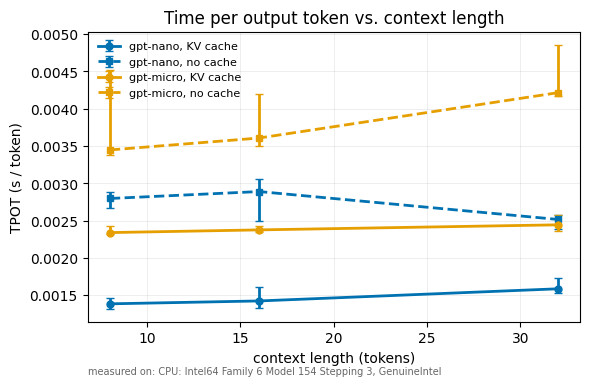

In [19]:
import matplotlib.pyplot as plt

# Okabe-Ito colorblind-safe palette, assigned in fixed order per model scale
SCALE_COLORS = {
    'gpt-nano': '#0072B2',
    'gpt-micro': '#E69F00',
    'gpt2': '#0072B2',
    'gpt2-medium': '#E69F00',
}

fig, ax = plt.subplots(figsize=(6, 4))
for model_type in MODEL_TYPES:
    for cached in [True, False]:
        sub = sweep_df[(sweep_df.model_type == model_type) & (sweep_df.cached == cached)].sort_values('prompt_len')
        if sub.empty:
            continue
        yerr = [sub.tpot_median - sub.tpot_min, sub.tpot_max - sub.tpot_median]
        ax.errorbar(
            sub.prompt_len, sub.tpot_median, yerr=yerr,
            color=SCALE_COLORS.get(model_type, '#555555'),
            linestyle='-' if cached else '--',
            marker='o' if cached else 's',
            markersize=5, linewidth=2, capsize=3,
            label=f"{model_type}, {'KV cache' if cached else 'no cache'}",
        )

ax.set_xlabel('context length (tokens)')
ax.set_ylabel('TPOT (s / token)')
ax.set_title('Time per output token vs. context length')
ax.text(0.0, -0.18, f'measured on: {device_name()}', transform=ax.transAxes,
        fontsize=7, color='#666666', ha='left')
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'fig1_tpot_vs_context.png', dpi=150)
plt.show()


## Figure 2: Peak VRAM vs. context length, measured vs. analytical

**Only meaningful on CUDA** — `peak_memory_bytes` is `None` on CPU (see the
device note at the top), so this cell will report the analytical curve only
when run locally and skip the measured series. Re-run on Colab for the real
comparison.


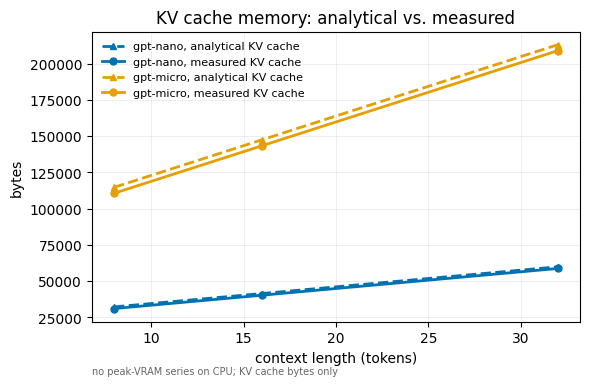

In [20]:
cache_rows = sweep_df[sweep_df.cached].sort_values('prompt_len')

fig, ax = plt.subplots(figsize=(6, 4))
for model_type in MODEL_TYPES:
    sub = cache_rows[cache_rows.model_type == model_type]
    if sub.empty:
        continue
    color = SCALE_COLORS.get(model_type, '#555555')
    ax.plot(sub.prompt_len, sub.kv_analytical_median, color=color, linestyle='--',
            marker='^', markersize=5, linewidth=2, label=f'{model_type}, analytical KV cache')
    ax.plot(sub.prompt_len, sub.kv_measured_median, color=color, linestyle='-',
            marker='o', markersize=5, linewidth=2, label=f'{model_type}, measured KV cache')
    if DEVICE == 'cuda' and sub.peak_mem_median.notna().any():
        ax.plot(sub.prompt_len, sub.peak_mem_median, color=color, linestyle=':',
                marker='s', markersize=5, linewidth=2, label=f'{model_type}, peak VRAM (measured)')

ax.set_xlabel('context length (tokens)')
ax.set_ylabel('bytes')
ax.set_title('KV cache memory: analytical vs. measured')
if DEVICE != 'cuda':
    ax.text(0.0, -0.18, 'no peak-VRAM series on CPU; KV cache bytes only', transform=ax.transAxes,
            fontsize=7, color='#666666', ha='left')
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'fig2_vram_vs_context.png', dpi=150)
plt.show()


## Pre-speculative-decoding diagnostics (local validation only)

Per `CLAUDE.md`, before writing `generate_speculative` we need two numbers:
(1) how forward-pass time scales with `T_q` (does verifying gamma+1 draft
tokens in one target pass actually stay cheap?), and (2) the cost ratio
`c = cost(draft) / cost(target)` for candidate model pairs.

**This run is local, on CPU, with `gpt-nano`/`gpt-micro` — it exists only to
de-risk the measurement code before spending Colab GPU time on it.** CPU and
GPU scale very differently with `T_q` (a GPU keeps more of that dimension
parallel), so these numbers are not the diagnostic result that goes in the
thesis — re-run the same cells on Colab with the real pairs
(`gpt-nano`/`gpt-mini`, `gpt2`/`gpt2-medium`) for that.


### T_q scan: does a longer verification pass stay cheap?

Prefills once, then times a single cached forward pass of `T_q` new tokens for
`T_q` in `{1, 5, 9}`. `rollback_kv_cache` resets the cache back to the same
prefill length before *each* timed variant, so all three measurements start
from identical cache state — without this, T_q=9 would be timed against a
cache already grown by the T_q=1 and T_q=5 runs, confounding the comparison.


In [21]:
def measure_tq_scan(model, prompt_len=32, tq_values=(1, 5, 9), n_warmup=3, n_reps=5):
    assert not model.vanilla, "T_q scan requires a KV-cached model"
    vocab_size = model.transformer.wte.num_embeddings

    set_seed(1234)
    prompt = torch.randint(0, vocab_size, (1, prompt_len), device=DEVICE)
    model.reset_kv_cache()
    with torch.no_grad():
        model(prompt, False)  # prefill
    prefill_len = model.transformer.h[0].attn.k_cache.size(2)
    assert prefill_len == prompt_len

    rows = []
    for tq in tq_values:
        for _ in range(n_warmup):
            model.rollback_kv_cache(prefill_len)
            new_tokens = torch.randint(0, vocab_size, (1, tq), device=DEVICE)
            device_sync()
            with torch.no_grad():
                model(new_tokens, True)
            device_sync()

        times = []
        for _ in range(n_reps):
            model.rollback_kv_cache(prefill_len)
            new_tokens = torch.randint(0, vocab_size, (1, tq), device=DEVICE)
            device_sync()
            t0 = time.perf_counter()
            with torch.no_grad():
                model(new_tokens, True)
            device_sync()
            t1 = time.perf_counter()
            times.append(t1 - t0)

        s = summarize(times)
        rows.append({'T_q': tq, 'time_median': s['median'], 'time_min': s['min'], 'time_max': s['max']})

    model.rollback_kv_cache(prefill_len)  # leave cache in a clean state
    return pd.DataFrame(rows)


set_seed(1234)
tq_model = GPT(make_toy_config(model_type='gpt-micro'), vanilla=False).to(DEVICE).eval()
tq_scan_df = measure_tq_scan(tq_model)
print(tq_scan_df)

# weak sanity check on the measurement code itself (not a scaling claim):
# a 9-token verification pass should cost measurably more than a 1-token one.
t1_median = tq_scan_df.loc[tq_scan_df.T_q == 1, 'time_median'].item()
t9_median = tq_scan_df.loc[tq_scan_df.T_q == 9, 'time_median'].item()
assert t9_median > t1_median, "T_q=9 was not slower than T_q=1 -- rollback/measurement logic is likely broken"
print(f"T_q=1 median: {t1_median:.6f}s, T_q=9 median: {t9_median:.6f}s -- measurement code looks sane")


number of parameters: 0.81M
   T_q  time_median  time_min  time_max
0    1     0.004456  0.004077  0.005903
1    5     0.004322  0.003857  0.005215
2    9     0.005338  0.004160  0.005719
T_q=1 median: 0.004456s, T_q=9 median: 0.005338s -- measurement code looks sane


### Cost ratio c = cost(draft) / cost(target)

Reuses `benchmark_config` unchanged — just run it once per model and compare
median TPOT. `gpt-nano` stands in for a cheap draft, `gpt-micro` for a more
expensive target; the point here is only that the ratio comes out below 1
(draft cheaper than target) and that the plumbing works, not the actual value.


In [22]:
def measure_cost_ratio(draft_model, target_model, prompt_len=32, max_new_tokens=20, n_reps=5):
    vocab_size = min(draft_model.transformer.wte.num_embeddings, target_model.transformer.wte.num_embeddings)
    set_seed(1234)
    prompt = torch.randint(0, vocab_size, (1, prompt_len), device=DEVICE)
    draft_result = benchmark_config(draft_model, prompt, max_new_tokens=max_new_tokens, n_reps=n_reps)
    target_result = benchmark_config(target_model, prompt, max_new_tokens=max_new_tokens, n_reps=n_reps)
    c = draft_result['summary']['tpot']['median'] / target_result['summary']['tpot']['median']
    return c, draft_result, target_result


set_seed(1234)
draft_model = GPT(make_toy_config(model_type='gpt-nano'), vanilla=False).to(DEVICE).eval()
set_seed(1234)
target_model = GPT(make_toy_config(model_type='gpt-micro'), vanilla=False).to(DEVICE).eval()

c_ratio, draft_result, target_result = measure_cost_ratio(draft_model, target_model)
print(f"draft (gpt-nano) TPOT median:  {draft_result['summary']['tpot']['median']:.6f}s")
print(f"target (gpt-micro) TPOT median: {target_result['summary']['tpot']['median']:.6f}s")
print(f"c = cost(draft)/cost(target) = {c_ratio:.3f}")

assert c_ratio < 1.0, "expected the smaller gpt-nano draft to be cheaper per token than the gpt-micro target"
print("measurement code looks sane: draft is cheaper than target, as expected")


number of parameters: 0.09M
number of parameters: 0.81M
draft (gpt-nano) TPOT median:  0.001850s
target (gpt-micro) TPOT median: 0.002866s
c = cost(draft)/cost(target) = 0.646
measurement code looks sane: draft is cheaper than target, as expected


## Figures 3-5 and summary table: blocked on speculative decoding

Per `CLAUDE.md`, figures 3 (speedup vs. gamma) and 4 (accept rate alpha) need
`generate_speculative`, which does not exist yet — these are intentionally
**not stubbed with fake data** here. Once Phase A (greedy) of speculative
decoding lands and passes its identity test, extend this notebook with:

- an `alpha` column recorded per call to `generate_speculative` (accepted /
  proposed tokens),
- a gamma sweep (1..8) reusing `benchmark_config` around
  `generate_speculative` the same way it wraps `generate`,
- the summary table (figure 5: baseline / cache / cache+speculative per model
  scale), built by concatenating this notebook's `sweep_df`-style rows with
  the speculative-decoding rows once they exist.

Do not backfill this table with baseline/cache numbers dressed up as
speculative-decoding results — an empty row is honest, a fabricated one is
worse than no data.
